# Notebook 3: Model Training

**Site Revenue Prediction ML System - SageMaker Notebook Series**

This notebook covers:
- Building the SiteScoringModel (Embedding + Residual MLP)
- Training loop with early stopping
- Learning rate scheduling
- Metric tracking and visualization
- Model checkpointing

## SageMaker Notes
- For GPU training, use `ml.g4dn.xlarge` (NVIDIA T4) or `ml.p3.2xlarge` (V100)
- For large datasets, use SageMaker Training jobs with distributed training
- Model artifacts should be saved to S3 for deployment

In [197]:
# 0. import necessary libraries and set up environment
import sys
import os
sys.path.insert(0, os.path.dirname(os.path.abspath('')))

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
import time
import json
import pickle

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

PyTorch version: 2.9.1
CUDA available: False
MPS available: True


#### 1. Load Processed Data and Configuration
###### a) Defines OUTPUT_DIR that points to ./outputs
###### b) Get model's hyperparameters from model_config.json
###### c) Displays configuration in terminal for verification
###### d) torch.load imports pre-process pytorch data file (processed_data.pt) that contains the training/validation datasets
###### e) Prints keys of data dictionary to confirm datasets have been loaded successfully

In [198]:
# 1a. Load Processed Data and Configuration
OUTPUT_DIR = Path('./outputs')

# Load model configuration
with open(OUTPUT_DIR / 'model_config.json', 'r') as f:
    config = json.load(f)

print("Model Configuration:")
for key, value in config.items():
    if key != 'categorical_vocab_sizes':
        print(f"  {key}: {value}")

# Load processed data
data = torch.load(OUTPUT_DIR / 'processed_data.pt', weights_only=False)
print(f"\nLoaded processed data with keys: {list(data.keys())}")

Model Configuration:
  n_numeric: 5
  n_boolean: 40
  n_categorical: 9
  task_type: regression
  target: avg_monthly_revenue
  device: mps
  batch_size: 4096

Loaded processed data with keys: ['numeric', 'categorical', 'boolean', 'target', 'train_idx', 'val_idx', 'test_idx']


In [199]:
# 1b. Load preprocessor for target inverse transform
with open(OUTPUT_DIR / 'preprocessor.pkl', 'rb') as f:
    preprocessor_data = pickle.load(f)

target_scaler = preprocessor_data['target_scaler']
print(f"Loaded target scaler: {target_scaler}")

Loaded target scaler: StandardScaler()


## 2. Define Model Architecture

The model uses:
- **Categorical Embeddings**: Learn dense representations for high-cardinality features

- **Residual Blocks**: Enable training deeper networks without vanishing gradients

- **Batch Normalization**: Stabilize training with large batch sizes

In [200]:
# 2. Define Model Architecture
class ResidualBlock(nn.Module):
    """Residual block with batch normalization."""
    
    def __init__(self, in_features, out_features, dropout=0.2):
        super().__init__()
        self.linear1 = nn.Linear(in_features, out_features)
        self.bn1 = nn.BatchNorm1d(out_features)
        self.linear2 = nn.Linear(out_features, out_features)
        self.bn2 = nn.BatchNorm1d(out_features)
        self.dropout = nn.Dropout(dropout)
        
        # Projection for residual if dimensions change
        self.projection = (
            nn.Linear(in_features, out_features)
            if in_features != out_features
            else nn.Identity()
        )
    
    def forward(self, x):
        residual = self.projection(x)
        out = torch.relu(self.bn1(self.linear1(x)))
        out = self.dropout(out)
        out = self.bn2(self.linear2(out))
        return torch.relu(out + residual)


class CategoricalEmbedding(nn.Module):
    """Embedding layer for categorical features."""
    
    def __init__(self, vocab_sizes, embedding_dim=16):
        super().__init__()
        self.embeddings = nn.ModuleDict()
        self.feature_names = list(vocab_sizes.keys())
        
        for name, vocab_size in vocab_sizes.items():
            # Use embedding dimension based on cardinality
            dim = min(embedding_dim, (vocab_size + 1) // 2)
            dim = max(dim, 4)  # Minimum dimension
            self.embeddings[name] = nn.Embedding(vocab_size + 1, dim, padding_idx=0)
        
        # Calculate total output dimension
        self.output_dim = sum(
            self.embeddings[name].embedding_dim for name in self.feature_names
        )
    
    def forward(self, x):
        embeddings = []
        for i, name in enumerate(self.feature_names):
            idx = x[:, i].clamp(0, self.embeddings[name].num_embeddings - 1)
            embeddings.append(self.embeddings[name](idx))
        return torch.cat(embeddings, dim=1)


class SiteScoringModel(nn.Module):
    """
    Neural network for site revenue/impression prediction.
    
    Architecture:
    1. Categorical features -> Embeddings -> Dense representation
    2. Numeric features -> BatchNorm -> Scaled representation
    3. Boolean features -> Direct concatenation
    4. Concatenate all -> Residual MLP blocks -> Output
    """
    
    def __init__(self, n_numeric, n_boolean, categorical_vocab_sizes,
                 embedding_dim=16, hidden_dims=None, dropout=0.2):
        super().__init__()
        hidden_dims = hidden_dims or [512, 256, 128, 64]
        
        # Categorical embeddings
        self.cat_embedding = CategoricalEmbedding(categorical_vocab_sizes, embedding_dim)
        
        # Numeric feature normalization
        self.numeric_bn = nn.BatchNorm1d(n_numeric) if n_numeric > 0 else None
        self.n_numeric = n_numeric
        self.n_boolean = n_boolean
        
        # Calculate input dimension
        total_input_dim = self.cat_embedding.output_dim + n_numeric + n_boolean
        
        # Build residual MLP
        layers = []
        in_dim = total_input_dim
        for out_dim in hidden_dims:
            layers.append(ResidualBlock(in_dim, out_dim, dropout))
            in_dim = out_dim
        
        self.mlp = nn.Sequential(*layers)
        
        # Output layer
        self.output = nn.Linear(hidden_dims[-1], 1)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        """Initialize weights for stable training."""
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight, gain=0.5)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0, std=0.02)
    
    def forward(self, numeric, categorical, boolean):
        # Process categorical through embeddings
        cat_embedded = self.cat_embedding(categorical)
        
        # Normalize numeric features
        if self.numeric_bn is not None and self.n_numeric > 0:
            numeric = self.numeric_bn(numeric)
        
        # Concatenate all features
        x = torch.cat([cat_embedded, numeric, boolean], dim=1)
        
        # Pass through MLP
        x = self.mlp(x)
        
        # Output
        return self.output(x)

print("Model classes defined")

Model classes defined


## 3. Create Dataset and DataLoaders
- **Residual Block**: Allows deeper networks by preventing vanishing gradient

- **CategoricalEmbedding**: Specialized layer for handling categorical features like IDs, categoris, and locations

- **SiteScoringModel (The Main Model)**: The primary class that assembles the previous components into a regression model.

- **Initialization**: includes _init_weights method that applies the Xavier Uniform initialization to Linear layers. This helps the model converge faster during the early stages of training

- **Output**: A single neuron indicating this is likely a regression task (predicting a continue value like revenue)

In [201]:
# 3a. Define Dataset Class and Create DataLoaders
class SiteDataset(Dataset):
    def __init__(self, numeric, categorical, boolean, target):
        self.numeric = numeric
        self.categorical = categorical
        self.boolean = boolean
        self.target = target
    
    def __len__(self):
        return len(self.target)
    
    def __getitem__(self, idx):
        return self.numeric[idx], self.categorical[idx], self.boolean[idx], self.target[idx]

# Extract data
numeric = data['numeric']
categorical = data['categorical']
boolean = data['boolean']
target = data['target']
train_idx = data['train_idx']
val_idx = data['val_idx']
test_idx = data['test_idx']

# Create datasets
train_dataset = SiteDataset(numeric[train_idx], categorical[train_idx], boolean[train_idx], target[train_idx])
val_dataset = SiteDataset(numeric[val_idx], categorical[val_idx], boolean[val_idx], target[val_idx])
test_dataset = SiteDataset(numeric[test_idx], categorical[test_idx], boolean[test_idx], target[test_idx])

print(f"Train: {len(train_dataset):,}, Val: {len(val_dataset):,}, Test: {len(test_dataset):,}")

Train: 15,927, Val: 3,413, Test: 3,414


In [202]:
# 3b. Configuration - Ensures Code Runs On Linux Servers and macOS
BATCH_SIZE = config.get('batch_size', 4096)

# Device selection and num_workers
# NOTE: On macOS, multiprocessing with DataLoader crashes (especially Python 3.13+)
import platform

if torch.cuda.is_available():
    device = torch.device('cuda')
    pin_memory = True
    NUM_WORKERS = 4  # Use multiprocessing on Linux/CUDA
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    pin_memory = False
    NUM_WORKERS = 0  # Disable multiprocessing on macOS (avoids fork issues)
else:
    device = torch.device('cpu')
    pin_memory = False
    NUM_WORKERS = 0 if platform.system() == 'Darwin' else 4

print(f"Using device: {device}")
print(f"Num workers: {NUM_WORKERS}")

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=NUM_WORKERS, pin_memory=pin_memory, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=pin_memory)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=pin_memory)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Using device: mps
Num workers: 0
Train batches: 3, Val batches: 1


## 4. Initialize Model

- **Purpose**: This step confirms the model is built correctly, fits on GPU, and has the expected complexity before beginning the resource-intensive training process

In [203]:
# Model hyperparameters
EMBEDDING_DIM = 16
HIDDEN_DIMS = [512, 256, 128, 64]
DROPOUT = 0.2

# Create model
model = SiteScoringModel(
    n_numeric=config['n_numeric'],
    n_boolean=config['n_boolean'],
    categorical_vocab_sizes=config['categorical_vocab_sizes'],
    embedding_dim=EMBEDDING_DIM,
    hidden_dims=HIDDEN_DIMS,
    dropout=DROPOUT,
)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel Architecture:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"\n{model}")


Model Architecture:
  Total parameters: 1,146,515
  Trainable parameters: 1,146,515

SiteScoringModel(
  (cat_embedding): CategoricalEmbedding(
    (embeddings): ModuleDict(
      (network): Embedding(5, 4, padding_idx=0)
      (program): Embedding(14, 7, padding_idx=0)
      (experience_type): Embedding(4, 4, padding_idx=0)
      (hardware_type): Embedding(18, 9, padding_idx=0)
      (retailer): Embedding(9737, 16, padding_idx=0)
      (brand_fuel): Embedding(140, 16, padding_idx=0)
      (brand_restaurant): Embedding(169, 16, padding_idx=0)
      (brand_c_store): Embedding(8140, 16, padding_idx=0)
      (nearest_interstate): Embedding(228, 16, padding_idx=0)
    )
  )
  (numeric_bn): BatchNorm1d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (mlp): Sequential(
    (0): ResidualBlock(
      (linear1): Linear(in_features=149, out_features=512, bias=True)
      (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (linear2):

## 5. Define Training Components

In [204]:
# Training configuration
EPOCHS = 500
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
SCHEDULER_PATIENCE = 5
EARLY_STOPPING_PATIENCE = 10

# Loss function - Huber loss is robust to outliers
criterion = nn.HuberLoss(delta=1.0)

# Optimizer with weight decay
optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=SCHEDULER_PATIENCE)

print(f"Training configuration:")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Early stopping patience: {EARLY_STOPPING_PATIENCE}")

Training configuration:
  Epochs: 500
  Learning rate: 0.0001
  Weight decay: 1e-05
  Early stopping patience: 10


In [205]:
@dataclass
class TrainingMetrics:
    """Container for training metrics."""
    train_loss: float
    val_loss: float
    val_mae: float
    val_r2: float
    epoch: int
    learning_rate: float

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0.0
    n_batches = 0
    
    for numeric, categorical, boolean, target in train_loader:
        # Move to device
        numeric = numeric.to(device, non_blocking=True)
        categorical = categorical.to(device, non_blocking=True)
        boolean = boolean.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        
        # Forward pass
        optimizer.zero_grad(set_to_none=True)
        predictions = model(numeric, categorical, boolean)
        loss = criterion(predictions, target)
        
        # Backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        n_batches += 1
    
    return total_loss / n_batches

@torch.no_grad()
def evaluate(model, val_loader, criterion, device, target_scaler):
    """Evaluate model on validation set."""
    model.eval()
    total_loss = 0.0
    all_predictions = []
    all_targets = []
    
    for numeric, categorical, boolean, target in val_loader:
        numeric = numeric.to(device, non_blocking=True)
        categorical = categorical.to(device, non_blocking=True)
        boolean = boolean.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)
        
        predictions = model(numeric, categorical, boolean)
        loss = criterion(predictions, target)
        
        total_loss += loss.item()
        all_predictions.append(predictions.cpu())
        all_targets.append(target.cpu())
    
    # Calculate metrics
    predictions = torch.cat(all_predictions).numpy()
    targets = torch.cat(all_targets).numpy()
    
    # Inverse transform to original scale
    if target_scaler is not None:
        predictions_orig = target_scaler.inverse_transform(predictions)
        targets_orig = target_scaler.inverse_transform(targets)
    else:
        predictions_orig = predictions
        targets_orig = targets
    
    # MAE in original scale
    mae = np.mean(np.abs(predictions_orig - targets_orig))
    
    # R² score
    ss_res = np.sum((targets_orig - predictions_orig) ** 2)
    ss_tot = np.sum((targets_orig - np.mean(targets_orig)) ** 2)
    r2 = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    
    return total_loss / len(val_loader), mae, r2

print("Training functions defined")

Training functions defined


## 6. Training Loop

In [ ]:
# Training state
best_val_loss = float('inf')
patience_counter = 0
training_history = []
best_model_state = None

print(f"\nStarting training for {EPOCHS} epochs...")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
print("=" * 80)

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()
    
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Evaluate
    val_loss, val_mae, val_r2 = evaluate(model, val_loader, criterion, device, target_scaler)
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Get current learning rate
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store metrics
    metrics = TrainingMetrics(
        train_loss=train_loss,
        val_loss=val_loss,
        val_mae=val_mae,
        val_r2=val_r2,
        epoch=epoch,
        learning_rate=current_lr,
    )
    training_history.append(metrics)
    
    # Print progress
    epoch_time = time.time() - epoch_start
    print(
        f"Epoch {epoch:3d}/{EPOCHS} ({epoch_time:.1f}s) | "
        f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
        f"MAE: ${val_mae:,.0f} | R²: {val_r2:.4f} | LR: {current_lr:.2e}"
    )
    
    # Check for improvement
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"  → New best model! (val_loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"\nEarly stopping triggered after {epoch} epochs")
            break

# Restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)

total_time = time.time() - start_time
print("=" * 80)
print(f"Training completed in {total_time/60:.1f} minutes")
print(f"Best validation loss: {best_val_loss:.4f}")


Starting training for 500 epochs...
Train batches: 3, Val batches: 1
Epoch   1/500 (0.2s) | Train: 0.5300 | Val: 0.3671 | MAE: $199 | R²: -0.0019 | LR: 1.00e-04
  → New best model! (val_loss: 0.3671)
Epoch   2/500 (0.1s) | Train: 0.4322 | Val: 0.3710 | MAE: $201 | R²: -0.0046 | LR: 1.00e-04
Epoch   3/500 (0.2s) | Train: 0.3793 | Val: 0.3719 | MAE: $201 | R²: -0.0048 | LR: 1.00e-04
Epoch   4/500 (0.1s) | Train: 0.3458 | Val: 0.3689 | MAE: $200 | R²: -0.0003 | LR: 1.00e-04
Epoch   5/500 (0.1s) | Train: 0.3162 | Val: 0.3628 | MAE: $198 | R²: 0.0074 | LR: 1.00e-04
  → New best model! (val_loss: 0.3628)
Epoch   6/500 (0.1s) | Train: 0.3060 | Val: 0.3553 | MAE: $194 | R²: 0.0156 | LR: 1.00e-04
  → New best model! (val_loss: 0.3553)
Epoch   7/500 (0.1s) | Train: 0.2945 | Val: 0.3465 | MAE: $190 | R²: 0.0256 | LR: 1.00e-04
  → New best model! (val_loss: 0.3465)
Epoch   8/500 (0.1s) | Train: 0.2911 | Val: 0.3371 | MAE: $185 | R²: 0.0378 | LR: 1.00e-04
  → New best model! (val_loss: 0.3371)
Epo

## 7. Visualize Training Progress

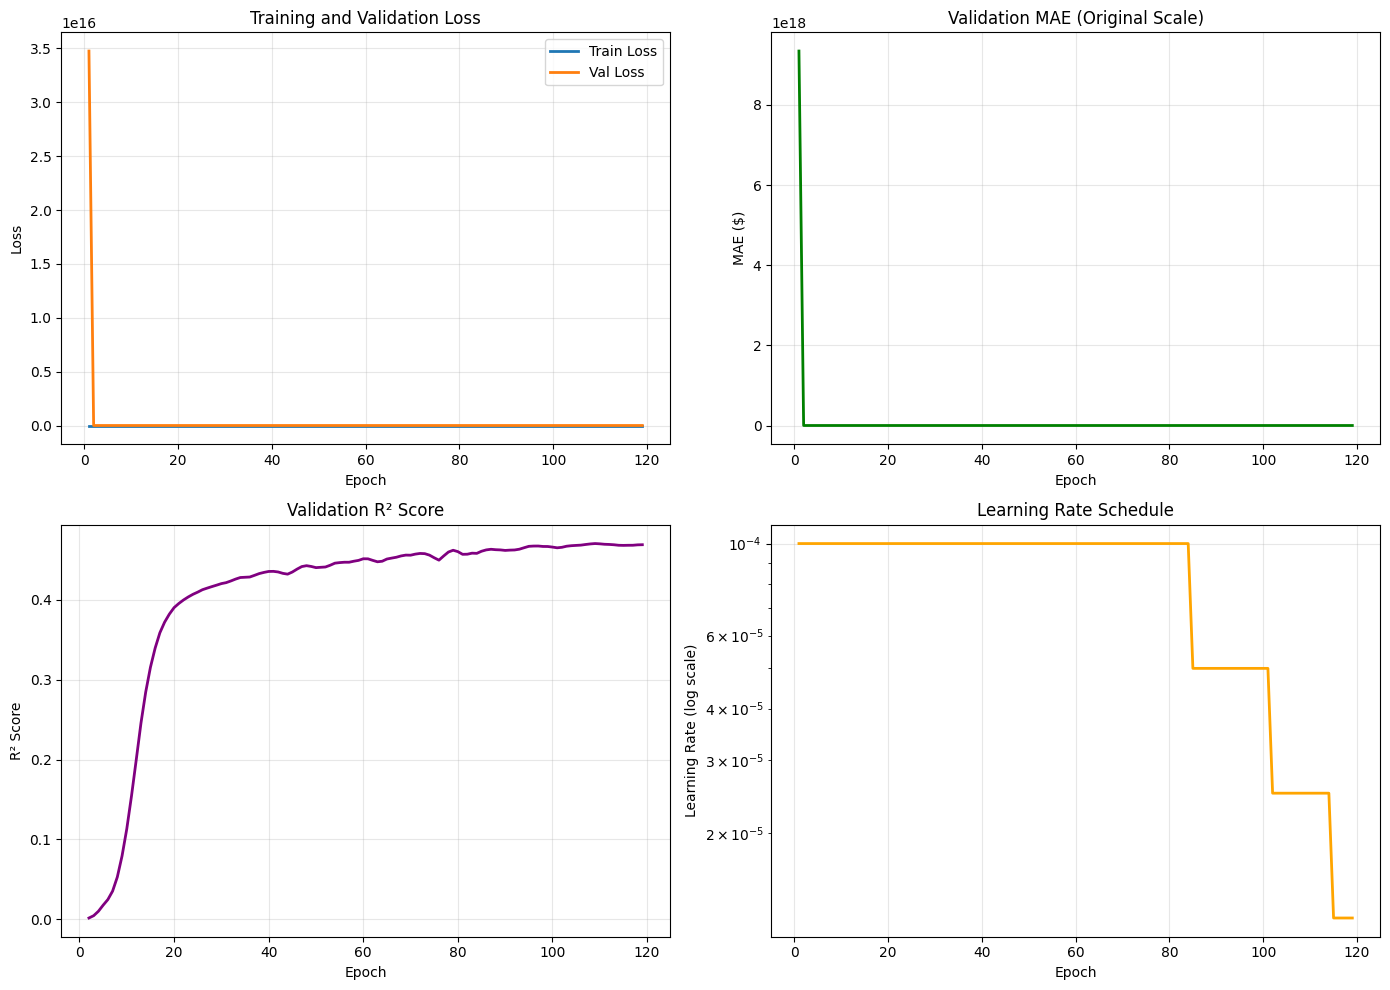

Training curves saved to outputs/training_curves.png


In [ ]:
# Extract metrics for plotting
epochs = [m.epoch for m in training_history]
train_losses = [m.train_loss for m in training_history]
val_losses = [m.val_loss for m in training_history]
val_maes = [m.val_mae for m in training_history]
val_r2s = [m.val_r2 for m in training_history]
learning_rates = [m.learning_rate for m in training_history]

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss curves
axes[0, 0].plot(epochs, train_losses, label='Train Loss', linewidth=2)
axes[0, 0].plot(epochs, val_losses, label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# MAE
axes[0, 1].plot(epochs, val_maes, color='green', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('MAE ($)')
axes[0, 1].set_title('Validation MAE (Original Scale)')
axes[0, 1].grid(True, alpha=0.3)

# R² Score
axes[1, 0].plot(epochs, val_r2s, color='purple', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].set_title('Validation R² Score')
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
axes[1, 1].semilogy(epochs, learning_rates, color='orange', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate (log scale)')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=150)
plt.show()

print(f"Training curves saved to {OUTPUT_DIR / 'training_curves.png'}")

## 8. Final Evaluation on Test Set

In [ ]:
# Evaluate on test set
test_loss, test_mae, test_r2 = evaluate(model, test_loader, criterion, device, target_scaler)

print("\nTest Set Results:")
print("=" * 40)
print(f"  Loss: {test_loss:.4f}")
print(f"  MAE:  ${test_mae:,.2f}")
print(f"  R²:   {test_r2:.4f}")


Test Set Results:
  Loss: 0.2142
  MAE:  $132.37
  R²:   0.4564


## 9. Save Model Checkpoint

In [ ]:
# Save model checkpoint
checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_loss': best_val_loss,
    'test_metrics': {
        'loss': test_loss,
        'mae': test_mae,
        'r2': test_r2,
    },
    'config': {
        'n_numeric': config['n_numeric'],
        'n_boolean': config['n_boolean'],
        'categorical_vocab_sizes': config['categorical_vocab_sizes'],
        'embedding_dim': EMBEDDING_DIM,
        'hidden_dims': HIDDEN_DIMS,
        'dropout': DROPOUT,
    },
    'training_history': [(m.epoch, m.train_loss, m.val_loss, m.val_mae, m.val_r2) 
                        for m in training_history],
}

torch.save(checkpoint, OUTPUT_DIR / 'best_model.pt')
print(f"Model checkpoint saved to {OUTPUT_DIR / 'best_model.pt'}")

Model checkpoint saved to outputs/best_model.pt


In [ ]:
# Save training summary
training_summary = {
    'total_epochs': len(training_history),
    'best_epoch': training_history[val_losses.index(min(val_losses))].epoch,
    'best_val_loss': float(best_val_loss),
    'final_train_loss': float(train_losses[-1]),
    'test_loss': float(test_loss),
    'test_mae': float(test_mae),
    'test_r2': float(test_r2),
    'total_training_time_minutes': total_time / 60,
    'model_parameters': total_params,
}

with open(OUTPUT_DIR / 'training_summary.json', 'w') as f:
    json.dump(training_summary, f, indent=2)

print(f"Training summary saved to {OUTPUT_DIR / 'training_summary.json'}")
print("\nSummary:")
for key, value in training_summary.items():
    print(f"  {key}: {value}")

Training summary saved to outputs/training_summary.json

Summary:
  total_epochs: 119
  best_epoch: 109
  best_val_loss: 0.2127971351146698
  final_train_loss: 0.19615945716698965
  test_loss: 0.2141612470149994
  test_mae: 132.3737335205078
  test_r2: 0.45640164613723755
  total_training_time_minutes: 0.21895126501719156
  model_parameters: 1146515


---

## Summary

This notebook has:
1. ✅ Defined the SiteScoringModel architecture (Embeddings + Residual MLP)
2. ✅ Implemented training loop with gradient clipping
3. ✅ Added early stopping and learning rate scheduling
4. ✅ Trained model with real-time metric tracking
5. ✅ Visualized training progress
6. ✅ Evaluated on held-out test set
7. ✅ Saved model checkpoint and training summary

**Artifacts created:**
- `outputs/best_model.pt` - Model weights and config
- `outputs/training_curves.png` - Training visualization
- `outputs/training_summary.json` - Training metrics

**Next:** Proceed to `04_evaluation_inference.ipynb` for detailed model evaluation and inference.